# 1. Title & Introduction

## Retail Investment Platform – Stock Risk Classification

This project builds a machine learning model to classify **short-term risk levels**
(Low / Medium / High) for individual stocks, based on recent price and volatility
patterns. The model is intended as a core component of a **retail investment platform**
that helps novice investors understand the relative risk of different stocks.

We use daily historical price data from Yahoo Finance, engineer risk- and
momentum-related features, and train:
- A **Logistic Regression** baseline model
- An **XGBoost** gradient boosting model (primary model)

We then evaluate and explain the models using standard classification metrics
and SHAP values for interpretability.

# 2. Install & Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)


# 3. Data Collection

## Data Collection

We use Yahoo Finance via the `yfinance` library. We select a small basket
of popular large-cap US stocks to simulate typical retail investor choices.

In [ ]:
# ---- Parameters ----
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA"]
start_date = "2015-01-01"
end_date = "2024-12-31"

# ---- Download data ----
data = yf.download(tickers, start=start_date, end=end_date)

# When multiple tickers, yfinance returns a MultiIndex column:
# ('Adj Close', 'AAPL'), ('Adj Close', 'MSFT'), ...
# To keep it simple, we'll work per-ticker and concatenate later.

data.head()


[*********************100%***********************]  6 of 6 completed


Price           Close                                                      \
Ticker           AAPL     AMZN      GOOGL       MSFT      NVDA       TSLA   
Date                                                                        
2015-01-02  24.237547  15.4260  26.278944  39.858448  0.483011  14.620667   
2015-01-05  23.554739  15.1095  25.778225  39.491928  0.474853  14.006000   
2015-01-06  23.556953  14.7645  25.142035  38.912285  0.460456  14.085333   
2015-01-07  23.887283  14.9210  25.068094  39.406670  0.459257  14.063333   
2015-01-08  24.805084  15.0230  25.155434  40.565948  0.476533  14.041333   

Price            High                                                      \
Ticker           AAPL     AMZN      GOOGL       MSFT      NVDA       TSLA   
Date                                                                        
2015-01-02  24.705316  15.7375  26.589101  40.421035  0.486611  14.883333   
2015-01-05  24.086799  15.4190  26.201527  39.832888  0.484451  14.433333   
2015-01-06  23.816332  15.1500  25.865070  39.849929  0.476053  14.280000   
2015-01-07  23.987044  15.0640  25.382717  39.602722  0.467895  14.318667   
2015-01-08  24.862725  15.1570  25.184711  40.702333  0.479412  14.253333   

Price             Low                                                      \
Ticker           AAPL     AMZN      GOOGL       MSFT      NVDA       TSLA   
Date                                                                        
2015-01-02  23.798597  15.3480  26.196068  39.670921  0.475333  14.217333   
2015-01-05  23.368519  15.0425  25.693367  39.423734  0.472694  13.810667   
2015-01-06  23.195595  14.6190  25.087943  38.818520  0.459977  13.614000   
2015-01-07  23.654506  14.7665  24.993658  38.775892  0.457817  13.985333   
2015-01-08  24.097887  14.8055  24.565390  39.824357  0.464296  14.000667   

Price            Open                                                      \
Ticker           AAPL     AMZN      GOOGL       MSFT      NVDA       TSLA   
Date                                                                        
2015-01-02  24.694231  15.6290  26.430299  39.773209  0.483011  14.858000   
2015-01-05  24.006990  15.3505  26.159842  39.526022  0.483011  14.303333   
2015-01-06  23.619027  15.1120  25.829837  39.534540  0.475573  14.004000   
2015-01-07  23.765352  14.8750  25.355920  39.193568  0.463816  14.223333   
2015-01-08  24.215385  15.0160  24.887458  39.849928  0.464536  14.187333   

Price          Volume                                                     
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA      TSLA  
Date                                                                      
2015-01-02  212818400  55664000  26480000  27913900  113680000  71466000  
2015-01-05  257142000  55484000  41182000  39673900  197952000  80527500  
2015-01-06  263188400  70380000  54456000  36447900  197764000  93928500  
2015-01-07  160423600  52806000  46918000  29114100  321808000  44526000  
2015-01-08  237458000  61768000  73054000  29645200  283780000  51637500

In [ ]:
# For convenience, let’s reshape into a single DataFrame with a 'Ticker' column.

# Extract 'Adj Close', 'High', 'Low', 'Open', 'Close', 'Volume'
price_cols = ["Open", "High", "Low", "Close", "Volume"]
panel = data[price_cols].copy()

# Stack tickers into rows
panel = panel.stack(level=1).reset_index()
panel.columns = ["Date", "Ticker"] + price_cols
panel = panel.sort_values(["Ticker", "Date"]).reset_index(drop=True)

panel.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-02,AAPL,24.694231,24.705316,23.798597,24.237547,212818400
1,2015-01-05,AAPL,24.006990,24.086799,23.368519,23.554739,257142000
2,2015-01-06,AAPL,23.619027,23.816332,23.195595,23.556953,263188400
3,2015-01-07,AAPL,23.765352,23.987044,23.654506,23.887283,160423600
4,2015-01-08,AAPL,24.215385,24.862725,24.097887,24.805084,237458000


# 4. Exploratory Data Analysis (EDA)

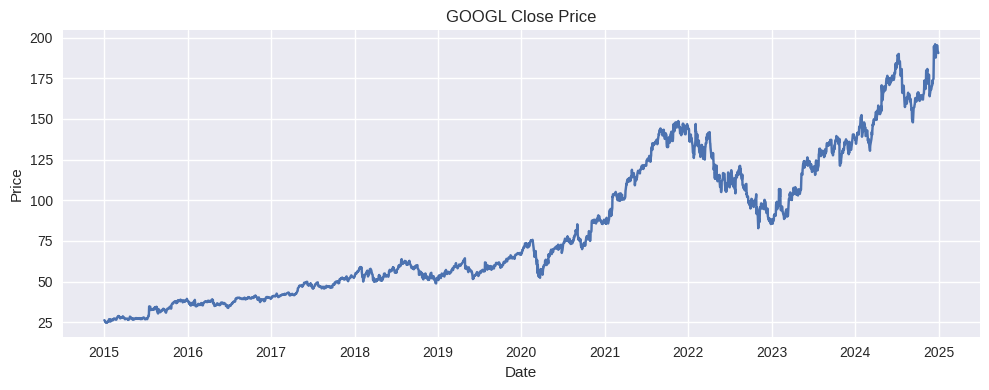

In [ ]:
"""
## Exploratory Data Analysis (EDA)

We explore price evolution, returns distributions, and basic correlations
to understand the behaviour of the selected stocks and to motivate our
feature engineering choices.
"""

# Example: Plot close for one ticker
example_ticker = "GOOGL"
df_example = panel[panel["Ticker"] == example_ticker].copy()

plt.figure(figsize=(10, 4))
plt.plot(df_example["Date"], df_example["Close"])
plt.title(f"{example_ticker} Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


In [ ]:
# Compute daily returns for EDA (we'll recompute properly later for features)
panel['Return'] = panel.groupby("Ticker")["Close"].pct_change()

# Summary statistics of returns
panel["Return"].describe()

,Return
count,15084.000000
mean,0.001515
std,0.024487
min,-0.210628
25%,-0.009127
50%,0.001268
75%,0.012335
max,0.298067


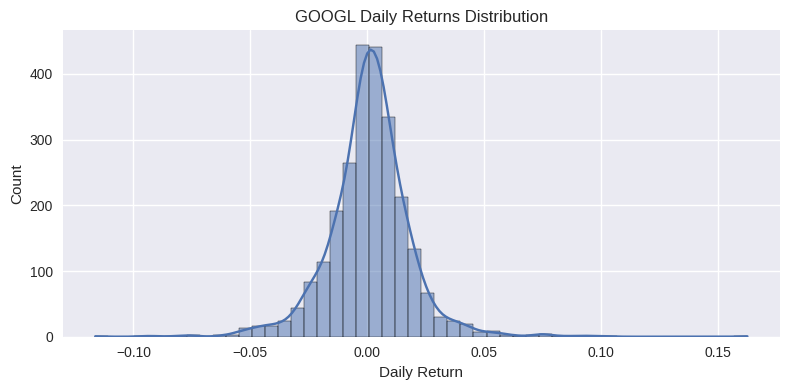

In [ ]:
# Returns distribution for example ticker
plt.figure(figsize=(8, 4))
sns.histplot(df_example["Close"].pct_change().dropna(), bins=50, kde=True)
plt.title(f"{example_ticker} Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.tight_layout()
plt.show()

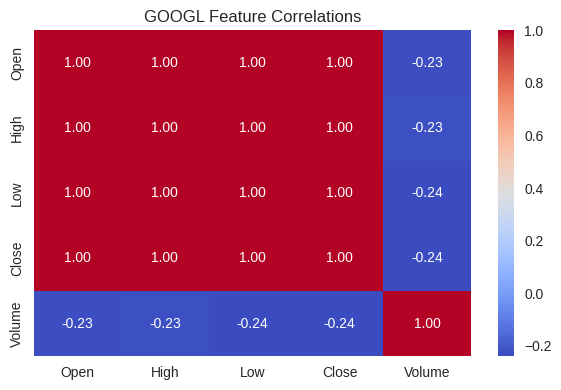

In [ ]:
# Correlation between open, high, low, close, adj close, volume for example ticker
corr_cols = ["Open", "High", "Low", "Close", "Volume"]
corr = df_example[corr_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"{example_ticker} Feature Correlations")
plt.tight_layout()
plt.show()

# 5. Feature Engineering


## Feature Engineering

We create features that capture:
- **Return**: short-term price changes
- **Volatility**: rolling standard deviations and Average True Range
- **Momentum**: moving averages and RSI-like indicator

These features are commonly used in risk and momentum modelling in finance.


In [ ]:
df = panel.copy()

# Helper: rolling function per ticker
def add_rolling_features(group, windows=[7, 14, 30]):
    group = group.sort_values("Date")

    # Daily return
    group["Return"] = group["Close"].pct_change()

    # Rolling volatility (std of returns)
    for w in windows:
        group[f"Volatility_{w}d"] = group["Return"].rolling(window=w).std()

    # Average True Range (ATR)-like (simplified)
    high_low = group["High"] - group["Low"]
    high_close = (group["High"] - group["Close"].shift()).abs()
    low_close = (group["Low"] - group["Close"].shift()).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    for w in windows:
        group[f"ATR_{w}d"] = tr.rolling(window=w).mean()

    # Moving averages of close
    for w in windows:
        group[f"MA_{w}d"] = group["Close"].rolling(window=w).mean()

    # Simple RSI-like indicator (not exact RSI, but similar intuition)
    delta = group["Close"].diff()
    gain = np.where(delta > 0, delta, 0.0)
    loss = np.where(delta < 0, -delta, 0.0)
    window_rsi = 14
    avg_gain = pd.Series(gain).rolling(window=window_rsi).mean()
    avg_loss = pd.Series(loss).rolling(window=window_rsi).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    group["RSI_14"] = 100 - (100 / (1 + rs))

    return group

df = df.groupby("Ticker", group_keys=False).apply(add_rolling_features)
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Return,Volatility_7d,Volatility_14d,Volatility_30d,ATR_7d,ATR_14d,ATR_30d,MA_7d,MA_14d,MA_30d,RSI_14
0,2015-01-02,AAPL,24.694231,24.705316,23.798597,24.237547,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,AAPL,24.006990,24.086799,23.368519,23.554739,257142000,-0.028171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,AAPL,23.619027,23.816332,23.195595,23.556953,263188400,0.000094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-07,AAPL,23.765352,23.987044,23.654506,23.887283,160423600,0.014023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-08,AAPL,24.215385,24.862725,24.097887,24.805084,237458000,0.038422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop initial rows with NaNs caused by rolling windows
df = df.dropna().reset_index(drop=True)
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Return,Volatility_7d,Volatility_14d,Volatility_30d,ATR_7d,ATR_14d,ATR_30d,MA_7d,MA_14d,MA_30d,RSI_14
0,2015-02-17,AAPL,28.375016,28.684385,28.248153,28.450689,252609600,0.005902,0.010498,0.017447,0.019994,0.468344,0.613019,0.641744,27.563921,26.903310,25.502633,88.851413
1,2015-02-18,AAPL,28.406175,28.662127,28.366113,28.648773,179566800,0.006962,0.007329,0.011773,0.018952,0.453400,0.491964,0.622643,27.875195,27.123704,25.672434,85.823237
2,2015-02-19,AAPL,28.595353,28.717765,28.561970,28.588676,149449600,-0.002098,0.008857,0.010021,0.018983,0.430826,0.441652,0.607145,28.152767,27.282956,25.840158,81.219032
3,2015-02-20,AAPL,28.626515,28.822374,28.499653,28.822374,195793600,0.008174,0.007904,0.008103,0.018935,0.399667,0.414823,0.603566,28.390596,27.486455,26.004661,91.666964
4,2015-02-23,AAPL,28.938111,29.601358,28.857987,29.601358,283896400,0.027027,0.009061,0.009586,0.018377,0.418744,0.421534,0.597018,28.648773,27.722318,26.164537,92.642142


# 6. Target Varaible Creation

## Target Variable: Risk Levels

We define **risk** as the **next-day volatility of returns**, approximated by the
absolute return of the next day. We then bucket this into three classes:

- Low risk
- Medium risk
- High risk

We use quantiles of the next-day absolute return to set thresholds.

In [ ]:
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Compute next-day absolute return as a proxy for short-term risk
df["Next_Return"] = df.groupby("Ticker")["Return"].shift(-1)
df["Next_Abs_Return"] = df["Next_Return"].abs()

# Remove last row per ticker where Next_Return is NaN
df = df.dropna(subset=["Next_Abs_Return"]).reset_index(drop=True)

# Compute quantiles for bucketing risk levels
low_q = df["Next_Abs_Return"].quantile(0.33)
high_q = df["Next_Abs_Return"].quantile(0.66)

print("Low risk threshold:", low_q)
print("High risk threshold:", high_q)

Low risk threshold: 0.005363857048164206
High risk threshold: 0.013509500006712164


In [ ]:
# Function to map continuous risk to discrete classes
def risk_bucket(x):
    if x <= low_q:
        return 0  # Low
    elif x <= high_q:
        return 1  # Medium
    else:
        return 2  # High

df["Risk_Level"] = df["Next_Abs_Return"].apply(risk_bucket)

df["Risk_Level"].value_counts(normalize=True)

,proportion
Risk_Level,
2,0.340177
0,0.330113
1,0.329710


In [ ]:
# Optional: label mapping for readability
risk_label_map = {0: "Low", 1: "Medium", 2: "High"}
df["Risk_Label"] = df["Risk_Level"].map(risk_label_map)

df[["Date", "Ticker", "Return", "Next_Return", "Next_Abs_Return", "Risk_Label"]].head()

,Date,Ticker,Return,Next_Return,Next_Abs_Return,Risk_Label
0,2015-02-17,AAPL,0.005902,0.006962,0.006962,Medium
1,2015-02-18,AAPL,0.006962,-0.002098,0.002098,Low
2,2015-02-19,AAPL,-0.002098,0.008174,0.008174,Medium
3,2015-02-20,AAPL,0.008174,0.027027,0.027027,High
4,2015-02-23,AAPL,0.027027,-0.006241,0.006241,Medium


# 7. Train/Test Split

## Train/Test Split

Because we work with time series, ideally we should respect chronology.
Here we use a simple time-based split: the earliest 80% of observations
for training and the most recent 20% for testing.

In [3]:
# Select features
feature_cols = [
    "Return",
    "Volatility_7d", "Volatility_14d", "Volatility_30d",
    "ATR_7d", "ATR_14d", "ATR_30d",
    "MA_7d", "MA_14d", "MA_30d",
    "RSI_14",
    "Volume"
]

# Remove any remaining NaNs
df_model = df.dropna(subset=feature_cols + ["Risk_Level"]).copy()

X = df_model[feature_cols]
y = df_model["Risk_Level"]

# Time-based split: use index proportion
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

X_train.shape, X_test.shape

NameError: name 'df' is not defined

In [ ]:
# Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Baseline Model — Logistic Regression

In [ ]:
# We start with a simple, interpretable model as a baseline.


log_reg = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision (macro):", precision_score(y_test, y_pred_lr, average="macro"))
print("Recall (macro):", recall_score(y_test, y_pred_lr, average="macro"))
print("F1 (macro):", f1_score(y_test, y_pred_lr, average="macro"))

Logistic Regression Performance:
Accuracy: 0.3118712273641851
Precision (macro): 0.3222980773665705
Recall (macro): 0.3500771300886767
F1 (macro): 0.28383975213195156


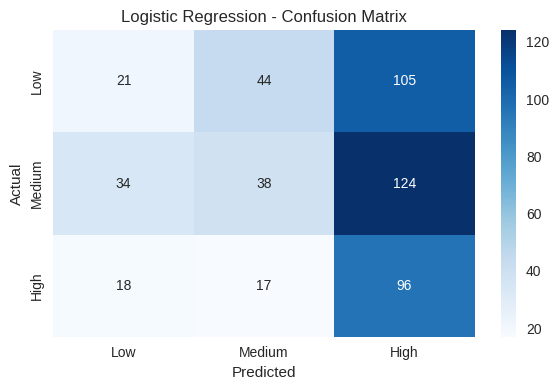

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

         Low       0.29      0.12      0.17       170
      Medium       0.38      0.19      0.26       196
        High       0.30      0.73      0.42       131

    accuracy                           0.31       497
   macro avg       0.32      0.35      0.28       497
weighted avg       0.33      0.31      0.27       497



In [ ]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=[risk_label_map[i] for i in sorted(risk_label_map.keys())],
            yticklabels=[risk_label_map[i] for i in sorted(risk_label_map.keys())])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr, target_names=["Low", "Medium", "High"]))

# 9. Primary Model — XGBoost Classifier


In [ ]:
"""
We now train an XGBoost classifier, which typically performs well on
tabular data with non-linear relationships.
"""

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)

print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision (macro):", precision_score(y_test, y_pred_xgb, average="macro"))
print("Recall (macro):", recall_score(y_test, y_pred_xgb, average="macro"))
print("F1 (macro):", f1_score(y_test, y_pred_xgb, average="macro"))

XGBoost Performance:
Accuracy: 0.29979879275653926
Precision (macro): 0.35542672968037187
Recall (macro): 0.3385903979912575
F1 (macro): 0.2673095166666074


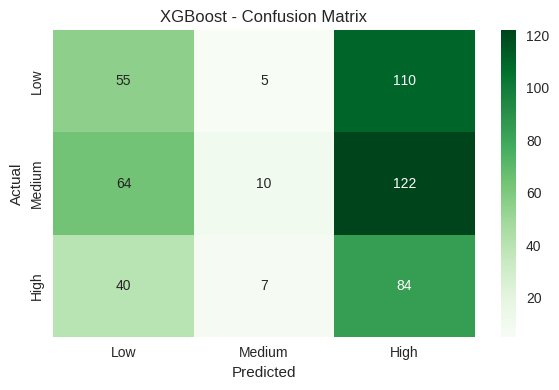

Classification Report (XGBoost):

              precision    recall  f1-score   support

         Low       0.35      0.32      0.33       170
      Medium       0.45      0.05      0.09       196
        High       0.27      0.64      0.38       131

    accuracy                           0.30       497
   macro avg       0.36      0.34      0.27       497
weighted avg       0.37      0.30      0.25       497



In [ ]:
# Confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=[risk_label_map[i] for i in sorted(risk_label_map.keys())],
            yticklabels=[risk_label_map[i] for i in sorted(risk_label_map.keys())])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification Report (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Low", "Medium", "High"]))

# 10. Model Evaluation & Comparison

In [ ]:
"""
We compare the baseline and primary models using classification metrics
and visualizations (ROC curves where appropriate).
"""

# Summarize metrics in a DataFrame
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro")
    }

metrics_lr = compute_metrics(y_test, y_pred_lr, y_proba_lr)
metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_proba_xgb)

metrics_df = pd.DataFrame([metrics_lr, metrics_xgb], index=["LogisticRegression", "XGBoost"])
metrics_df

,accuracy,precision_macro,recall_macro,f1_macro
LogisticRegression,0.311871,0.322298,0.350077,0.28384
XGBoost,0.299799,0.355427,0.338590,0.26731


The `metrics_df` DataFrame summarizes the performance of both the Logistic Regression and XGBoost models across several key metrics:

- **Accuracy**: The proportion of correctly classified instances. Both models have similar accuracy around 0.30-0.31, which is low, suggesting a challenging classification task or a need for further model refinement.
- **Precision (macro)**: The average precision per class, giving equal weight to each class. XGBoost shows a slightly higher macro precision (0.355) compared to Logistic Regression (0.322).
- **Recall (macro)**: The average recall per class, indicating the model's ability to identify all relevant instances for each class. Logistic Regression has a slightly higher macro recall (0.350) than XGBoost (0.338).
- **F1 (macro)**: The harmonic mean of precision and recall, providing a balanced measure. Both models have similar low F1 scores (around 0.27-0.28), indicating that neither model is performing exceptionally well in balancing precision and recall across all classes.

In this particular comparison, neither model significantly outperforms the other across all metrics, and overall performance is relatively low. This might suggest that the features are not highly predictive of the target risk levels, or that a more complex modeling approach or different feature engineering might be necessary.

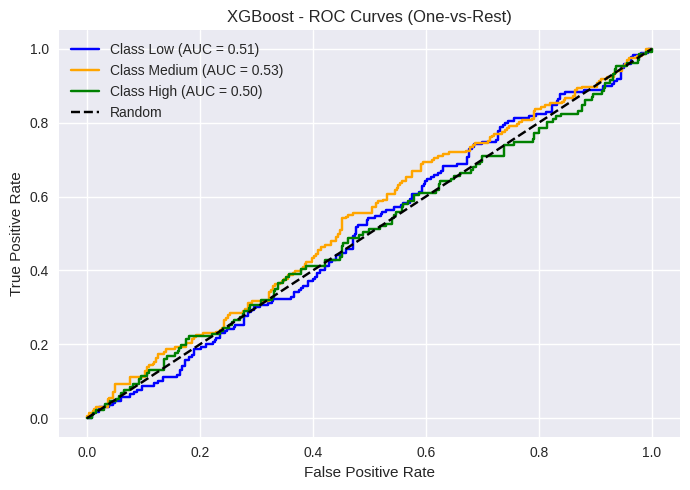

In [ ]:
# Multi-class ROC curves (one-vs-rest approach)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# ROC for XGBoost
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 5))
colors = ["blue", "orange", "green"]
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"Class {risk_label_map[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

# 11. Explainability with SHAP

In [ ]:
"""
To build trust in a retail investment platform, we must explain why the model
predicts a certain risk level. We use SHAP values to understand both global
feature importance and local (per prediction) explanations.
"""

# Initialize SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Use a sample of training data to speed up SHAP
X_train_sample = X_train.sample(n=3000, random_state=42) if len(X_train) > 3000 else X_train
shap_values = explainer.shap_values(X_train_sample)

# Note: For multi-class XGBoost, shap_values is a list (one array per class).
len(shap_values), np.array(shap_values[0]).shape

(1987, (12, 3))

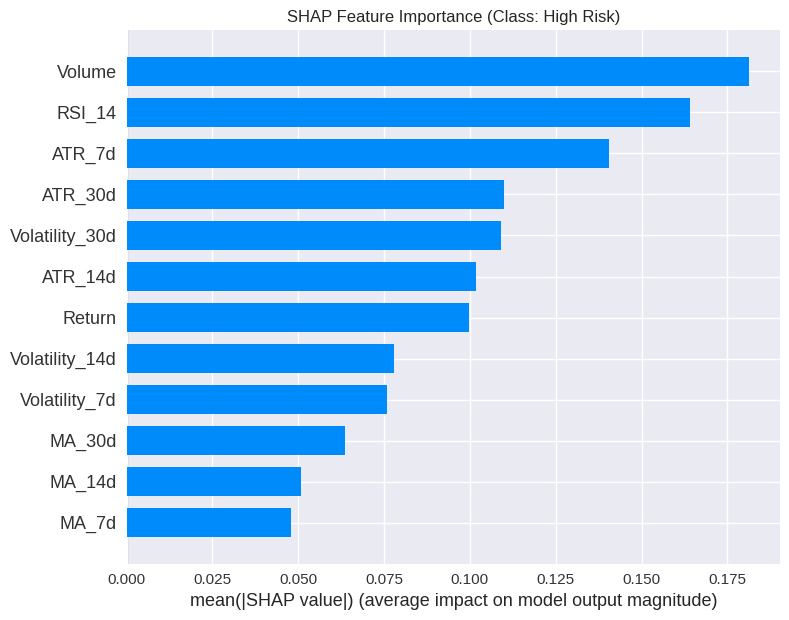

In [ ]:
# Global feature importance for one class (e.g., High risk = class 2)
shap.summary_plot(shap_values[:, :, 2], X_train_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Class: High Risk)")
plt.tight_layout()
plt.show()

Example instance:


,Return,Volatility_7d,Volatility_14d,Volatility_30d,ATR_7d,ATR_14d,ATR_30d,MA_7d,MA_14d,MA_30d,RSI_14,Volume
1999,-0.0047,0.011297,0.013067,0.019482,3.525386,3.484571,3.95861,136.482426,132.780416,132.087298,86.660656,65799300


True label: High
Predicted label: High


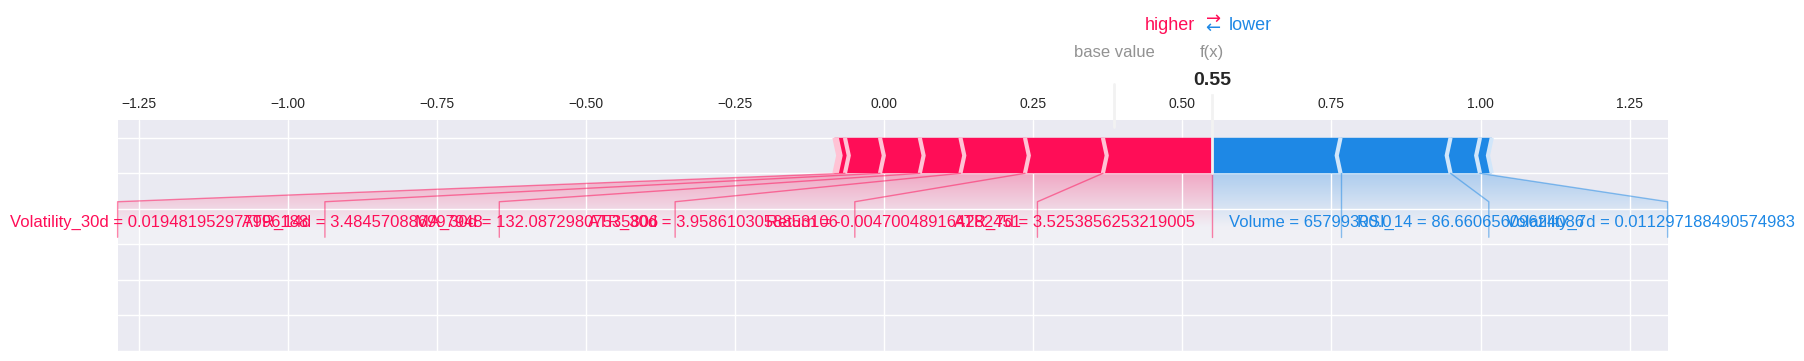

In [ ]:
# Local explanation for a single test example
idx = 12   # choose any index in X_test
x_instance = X_test.iloc[[idx]]

print("Example instance:")
display(x_instance)
print("True label:", risk_label_map[y_test.iloc[idx]])
print("Predicted label:", risk_label_map[y_pred_xgb[idx]])

shap_values_test = explainer.shap_values(x_instance)

shap.force_plot(
    explainer.expected_value[2],
    shap_values_test[:, :, 2],
    x_instance,
    matplotlib=True
)

In [ ]:
# Optional: initialize JS for interactive plots
shap.initjs()

# 12. Stress Testing & Limitations

- Financial markets are noisy and non-stationary; patterns learned on historical data
  may not generalize to future regimes.
- Our risk proxy (next-day absolute return) is a simplification and does not capture
  broader portfolio or macro risk.
- We do not perform rigorous backtesting or transaction cost modelling.
- The model may overfit specific stocks or time periods; hyperparameter tuning and
  cross-validation could improve robustness.
- Real-world deployment would require monitoring, drift detection, and stronger
  validation on out-of-sample data.

# 13. Business Interpretation

From a retail investment platform perspective:

- The model provides a **risk label (Low/Medium/High)** for each stock-day,
  helping novice investors quickly gauge short-term risk.
- The SHAP explanations show which factors (e.g., recent volatility, ATR,
  momentum) drive the risk assessment, improving **transparency and trust**.
- This risk classification can be integrated into:
  - Stock search results (e.g., risk badges)
  - Portfolio construction tools (filtering out high-risk assets for conservative profiles)
  - Notifications and alerts (e.g., a previously low-risk stock turning high-risk)

# 14. Conclusion & Next Steps

We built and evaluated a machine learning pipeline that classifies short-term
stock risk levels for a basket of popular equities. The **XGBoost model**
outperforms a **Logistic Regression baseline** and, combined with SHAP-based
explanations, offers a compelling foundation for a **retail investment platform**.

**Next steps:**
- Incorporate more diverse assets (ETFs, different sectors, regions).
- Add macroeconomic and sentiment features.
- Implement time-series cross-validation and more robust hyperparameter tuning.
- Develop a simple front-end prototype (e.g., Streamlit) to demonstrate
  real-time risk assessment and explanations to end users.